# fio DFS All-Patterns Analysis

Analyzes `rand_write / rand_read / mixed` and `seq_write / seq_read / mixed` results
across block sizes (numjobs=32, iodepth=8). The `prefill` job is excluded.

In [1]:
import json
import re
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

RESULTS_DIR = Path(".")

In [2]:
def parse_file(fpath):
    m = re.search(r"fio_bs(\S+?)_nj(\d+)_iod(\d+)_", Path(fpath).name)
    bs, nj, iod = m.group(1), int(m.group(2)), int(m.group(3))

    with open(fpath) as f:
        d = json.load(f)

    rows = []
    for job in d["jobs"]:
        name = job["jobname"]
        if name == "prefill":
            continue

        def ms(v): return v / 1e6

        if "mixed" in job:
            # unified_rw_reporting=1: read+write combined in "mixed"
            mx = job["mixed"]
            bw_GiBs     = mx["bw"] / 1024 / 1024
            iops        = mx["iops"]
            lat_max_ms  = ms(mx["lat_ns"]["max"])
            lat_mean_ms = ms(mx["lat_ns"]["mean"])
        else:
            r = job["read"]
            w = job["write"]
            has_read  = r["total_ios"] > 0
            has_write = w["total_ios"] > 0

            bw_GiBs = (r["bw"] * has_read + w["bw"] * has_write) / 1024 / 1024
            iops    =  r["iops"] * has_read + w["iops"] * has_write

            candidates = []
            if has_read:  candidates.append(r["lat_ns"]["max"])
            if has_write: candidates.append(w["lat_ns"]["max"])
            lat_max_ms = ms(max(candidates)) if candidates else 0

            mean_num = (r["lat_ns"]["mean"] * r["total_ios"] * has_read +
                        w["lat_ns"]["mean"] * w["total_ios"] * has_write)
            mean_den = r["total_ios"] * has_read + w["total_ios"] * has_write
            lat_mean_ms = ms(mean_num / mean_den) if mean_den > 0 else 0

        rows.append(dict(
            block_size  = bs,
            numjobs     = nj,
            iodepth     = iod,
            pattern     = name,
            bw_GiBs     = bw_GiBs,
            iops        = iops,
            lat_mean_ms = lat_mean_ms,
            lat_max_ms  = lat_max_ms,
        ))
    return rows


all_rows = []
for fpath in sorted(RESULTS_DIR.glob("*.json")):
    all_rows.extend(parse_file(fpath))

BS_ORDER = ["4k", "16k", "1m", "2m", "4m"]
PATTERN_ORDER = [
    "rand_read", "rand_readH", "rand_readB", "rand_writeH", "rand_write", 
    "seq_read",  "seq_readH",  "seq_readB",  "seq_writeH", "seq_write"
]

df = pd.DataFrame(all_rows)
df["block_size"] = pd.Categorical(df["block_size"], categories=BS_ORDER, ordered=True)
df["pattern"]    = pd.Categorical(df["pattern"],    categories=PATTERN_ORDER, ordered=True)
df = df.sort_values(["block_size", "pattern"]).reset_index(drop=True)

print(f"Loaded {len(df)} jobs from {df['block_size'].nunique()} block size(s)")
df

Loaded 50 jobs from 5 block size(s)


,block_size,numjobs,iodepth,pattern,bw_GiBs,iops,lat_mean_ms,lat_max_ms
0,4k,32,8,rand_read,2.251763,5.902864e+05,0.433204,75.657647
1,4k,32,8,rand_readH,1.932265,5.065318e+05,0.504670,114.994635
2,4k,32,8,rand_readB,2.564222,6.721957e+05,0.380085,91.333797
3,4k,32,8,rand_writeH,4.706023,1.233656e+06,0.206825,116.372595
4,4k,32,8,rand_write,6.734276,1.765350e+06,0.144325,96.237236
5,4k,32,8,seq_read,1.394795,3.656374e+05,0.699687,40.904282
6,4k,32,8,seq_readH,1.610145,4.220900e+05,0.605906,42.209931
7,4k,32,8,seq_readB,2.288217,5.998424e+05,0.426172,37.498226
8,4k,32,8,seq_writeH,3.438712,9.014379e+05,0.283309,47.899109
9,4k,32,8,seq_write,4.361400,1.143315e+06,0.223229,46.296303


## Mean/Max Latency (ms)

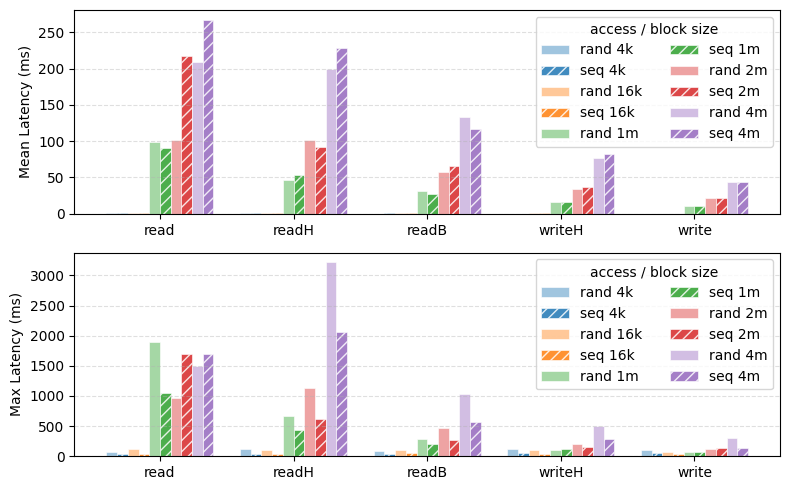

In [8]:
BASE_OPS = ["read", "readH", "readB", "writeH", "write"]
ACCESS   = ["rand", "seq"]
_hatches = {"rand": "", "seq": "///"}

def plot_metric(ax, col):
    bs_l    = sorted(df["block_size"].unique(), key=lambda b: BS_ORDER.index(b))
    combos  = [(acc, bs) for bs in bs_l for acc in ACCESS]
    n       = len(combos)
    bar_w   = 0.8 / n
    x       = list(range(len(BASE_OPS)))
    offsets = [(i - (n - 1) / 2) * bar_w for i in range(n)]
    clrs    = plt.cm.tab10.colors

    sub_all = df.set_index(["block_size", "pattern"])[col]
    for i, (acc, bs) in enumerate(combos):
        vals     = [sub_all.get((bs, f"{acc}_{op}"), 0) for op in BASE_OPS]
        base_clr = clrs[bs_l.index(bs)]
        # rand bars: lighten to 50% by blending with white; seq bars: full color
        bar_clr  = tuple(c * 0.5 + 0.5 for c in base_clr[:3]) if acc == "rand" else base_clr
        ax.bar([xi + offsets[i] for xi in x], vals, bar_w,
               label=f"{acc} {bs}",
               color=bar_clr,
               hatch=_hatches[acc], alpha=0.85, edgecolor="white", linewidth=0.5)
    return x, bs_l

fig, axes = plt.subplots(2, 1, figsize=(8, 5))

for ax, (col, title) in zip(axes, [
    ("lat_mean_ms", "Mean Latency (ms)"),
    ("lat_max_ms",  "Max Latency (ms)"),
]):
    x_ticks, bs_l = plot_metric(ax, col)
    ax.set_xticks(x_ticks)
    ax.set_xticklabels(BASE_OPS)
    ax.set_ylabel(title)
    ax.legend(title="access / block size", loc="upper right", ncol=2)
    ax.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.savefig(RESULTS_DIR / "latency-all-pattern.pdf", dpi=150)
plt.show()

## Bandwidth (GiB/s)

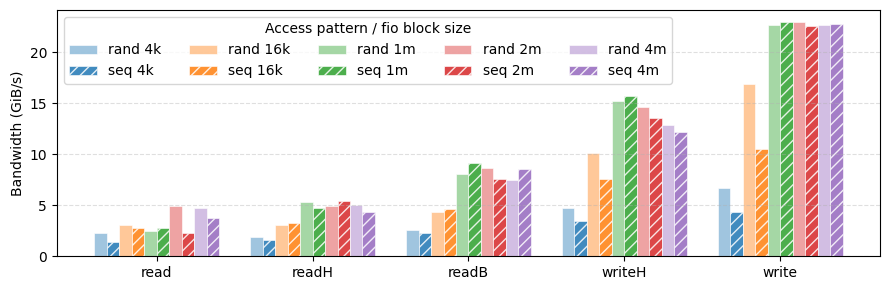

In [4]:
fig, ax = plt.subplots(figsize=(9, 3))
x_ticks, bs_l = plot_metric(ax, "bw_GiBs")
ax.set_xticks(x_ticks)
ax.set_xticklabels(BASE_OPS)
ax.set_ylabel("Bandwidth (GiB/s)")
ax.legend(title="Access pattern / fio block size", loc="upper left", ncol=5)
ax.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "bw-all-pattern.pdf", dpi=150)
plt.show()

## CPU Usage (usr / sys)

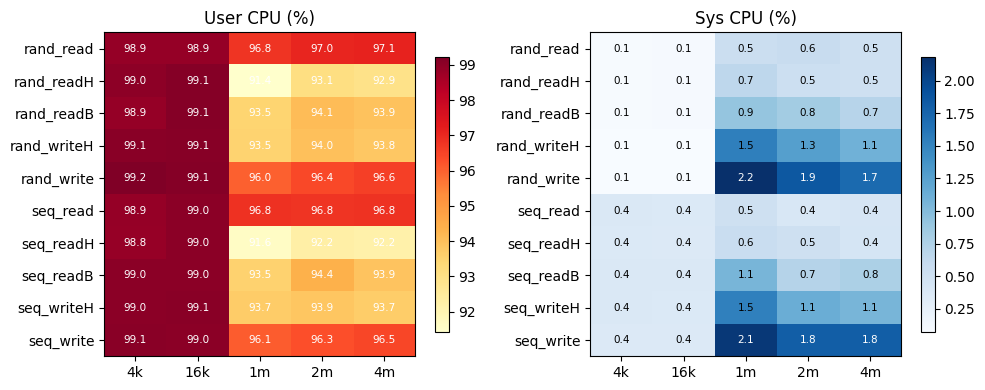

In [9]:
cpu_rows = []
for fpath in sorted(RESULTS_DIR.glob("*.json")):
    m = re.search(r"fio_bs(\S+?)_nj(\d+)_iod(\d+)_", Path(fpath).name)
    bs = m.group(1)
    with open(fpath) as f:
        d = json.load(f)
    for job in d["jobs"]:
        if job["jobname"] == "prefill":
            continue
        cpu_rows.append(dict(
            block_size = bs,
            pattern    = job["jobname"],
            usr_cpu    = job["usr_cpu"],
            sys_cpu    = job["sys_cpu"],
        ))

df_cpu = pd.DataFrame(cpu_rows)
df_cpu["block_size"] = pd.Categorical(df_cpu["block_size"], categories=BS_ORDER, ordered=True)
df_cpu["pattern"]    = pd.Categorical(df_cpu["pattern"],    categories=PATTERN_ORDER, ordered=True)

pivot_usr = df_cpu.pivot(index="pattern", columns="block_size", values="usr_cpu")
pivot_sys = df_cpu.pivot(index="pattern", columns="block_size", values="sys_cpu")

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, pivot, title, cmap in zip(
    axes,
    [pivot_usr, pivot_sys],
    ["User CPU (%)", "Sys CPU (%)"],
    ["YlOrRd", "Blues"],
):
    im = ax.imshow(pivot.values, aspect="auto", cmap=cmap,
                   vmin=pivot.values.min(), vmax=pivot.values.max())
    ax.set_xticks(range(len(pivot.columns)))
    ax.set_xticklabels(pivot.columns)
    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels(pivot.index)
    ax.set_title(title)
    plt.colorbar(im, ax=ax, shrink=0.85)
    for i in range(len(pivot.index)):
        for j in range(len(pivot.columns)):
            ax.text(j, i, f"{pivot.values[i, j]:.1f}",
                    ha="center", va="center", fontsize=7.5,
                    color="black" if pivot.values[i, j] < pivot.values.max() * 0.75 else "white")

plt.tight_layout()
plt.savefig(RESULTS_DIR / "cpu_usage.pdf", dpi=150)
plt.show()

## Key Findings

**Setup:** fio via DAOS DFS API, numjobs=32, iodepth=8, block sizes 4k–4m.
Patterns: `read`, `readH` (read-heavy mixed), `readB` (read-biased mixed), `writeH` (write-heavy mixed), `write`.

---

### 1. Write throughput saturates at ~22–23 GiB/s for large block sizes
Both `rand_write` and `seq_write` reach ~22–23 GiB/s at ≥1 MiB block sizes,
with essentially no difference between sequential and random access.
DAOS VOS absorbs random writes as sequential appends to its log, eliminating the
rand/seq distinction once the I/O size is large enough to saturate the network.

### 2. Random write outperforms sequential write at small block sizes
At 4k: `rand_write` 6.7 GiB/s vs `seq_write` 4.4 GiB/s (+52%).
At 16k: `rand_write` 16.8 GiB/s vs `seq_write` 10.5 GiB/s (+60%).
With 32 independent jobs, random offsets spread load across more server shards,
achieving better server-side parallelism than sequential striding.

### 3. Read throughput is 5–10× lower than write at large block sizes
At 1 MiB: `rand_write` / `rand_read` ≈ 9× (22.7 vs 2.5 GiB/s).
Reads see no equivalent buffering benefit — every fetch is a cold miss through
the full DAOS client → network → server → storage stack.

### 4. Sequential reads do not outperform random reads — and sometimes lag behind
At 2 MiB: `seq_read` 2.3 GiB/s vs `rand_read` 4.9 GiB/s.
At 4 MiB: `seq_read` 3.7 GiB/s vs `rand_read` 4.8 GiB/s.
DAOS does not implement traditional read-ahead, so sequential access provides
no prefetch advantage. Random access with many jobs can even yield better
server-side dispatch parallelism.

### 5. Mixed patterns (readB > readH > pure read) at every block size
At 1 MiB: `rand_readB` 8.1, `rand_readH` 5.3, `rand_read` 2.5 GiB/s.
Patterns with a write component keep recently written data warm in the DAOS
server DRAM cache, improving effective read throughput for the read portion.

### 6. Read mean latency grows ~480× from 4k to 4m
`rand_read` mean latency: 0.43 ms (4k) → 208 ms (4m).
Write mean latency by contrast: 0.14 ms (4k) → 44 ms (4m), growing much more
slowly and reflecting the fast VOS log-append path.

### 7. Tail latency is extreme for large-block random reads
`rand_readH` at 4m: **3.2 s max latency** (vs 297 ms for `rand_write` at 4m).
Pure writes remain well-bounded. Read tail latencies indicate occasional severe
queuing or server-side GC interference under heavy random large-block read load.